# GraphSmile — Stage Cluster-Quality Metrics (native space, cosine)

Measures — in the **original high-dimensional feature space**, with **NO dimensionality reduction** — whether emotion clusters form and how separable they are at each stage of the GraphSmile forward pass.

**Why no PCA/t-SNE:** projections distort distances (t-SNE is non-metric, PCA collapses variance), so any metric computed on 2D coords measures the projection artifact, not the real geometry. All metrics here run on raw stage features with **cosine distance**.

## Metrics
- **Primary — k-NN label consistency (cosine):** for each utterance, fraction of its k nearest neighbors (cosine) that share the same emotion. Purity in [0,1].
- **Secondary — per-class silhouette (cosine):** `silhouette_samples(X, labels, metric='cosine')` on raw features, aggregated per emotion.
- **Supporting — centroid cosine distance:** pairwise cosine distance between per-emotion mean vectors.

## Stages captured
| Key | Stage | Modality | Dim |
|-----|-------|----------|-----|
| `raw_t/v/a` | Raw input | Text / Visual / Audio | 1024 / 342 / 1582 |
| `proj_t/v/a` | After `dim_layer_*` | each | 256 |
| `graph_tv_t/v` | After `hetergconv_tv` | Text / Visual | 256 |
| `graph_ta_t/a` | After `hetergconv_ta` | Text / Audio | 256 |
| `graph_va_v/a` | After `hetergconv_va` | Visual / Audio | 256 |
| `fusion` | After `modal_fusion` | Multimodal | 256 |

**Prerequisite:** run training with `--save_feats --save_feats_path results/stage_feats.pkl`

In [13]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_samples
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

STAGE_FEATS_PATH = 'results/stage_feats.pkl'
RANDOM_SEED = 42

EMOTION_LABELS = {0: 'anger', 1: 'happiness', 2: 'sadness',
                  3: 'neutral', 4: 'frustration', 5: 'excitement'}
COLORS = {0: '#e74c3c', 1: '#f39c12', 2: '#3498db',
          3: '#95a5a6', 4: '#9b59b6', 5: '#2ecc71'}
N_EMO = len(EMOTION_LABELS)
LEGEND_PATCHES = [mpatches.Patch(color=COLORS[k], label=v) for k, v in EMOTION_LABELS.items()]

def stage_group(key):
    if key.startswith('raw'):   return 'raw'
    if key.startswith('proj'):  return 'proj'
    if key.startswith('graph'): return 'graph'
    return 'fusion'
GROUP_COLOR = {'raw': '#3498db', 'proj': '#e67e22', 'graph': '#9b59b6', 'fusion': '#e74c3c'}

In [14]:
with open(STAGE_FEATS_PATH, 'rb') as f:
    sf = pickle.load(f)

labels = sf['labels'].astype(int)
N = len(labels)
print(f'Loaded stage features. Utterances: {N}')

# Ordered stage list (only keys present in the file)
STAGE_ORDER = ['raw_t', 'raw_v', 'raw_a',
               'proj_t', 'proj_v', 'proj_a',
               'graph_tv_t', 'graph_tv_v',
               'graph_ta_t', 'graph_ta_a',
               'graph_va_v', 'graph_va_a',
               'fusion']
FEAT_KEYS = [k for k in STAGE_ORDER if k in sf]
print('Stages:', FEAT_KEYS)
for k in FEAT_KEYS:
    print(f'  {k:12s} shape={sf[k].shape}')

print('\nLabel distribution:')
for k, v in EMOTION_LABELS.items():
    n = (labels == k).sum()
    print(f'  {k} {v:12s}: {n:4d} ({100*n/N:.1f}%)')

Loaded stage features. Utterances: 1623
Stages: ['raw_t', 'raw_v', 'raw_a', 'proj_t', 'proj_v', 'proj_a', 'graph_tv_t', 'graph_tv_v', 'graph_ta_t', 'graph_ta_a', 'graph_va_v', 'graph_va_a', 'fusion']
  raw_t        shape=(1623, 1024)
  raw_v        shape=(1623, 342)
  raw_a        shape=(1623, 1582)
  proj_t       shape=(1623, 512)
  proj_v       shape=(1623, 512)
  proj_a       shape=(1623, 512)
  graph_tv_t   shape=(1623, 512)
  graph_tv_v   shape=(1623, 512)
  graph_ta_t   shape=(1623, 512)
  graph_ta_a   shape=(1623, 512)
  graph_va_v   shape=(1623, 512)
  graph_va_a   shape=(1623, 512)
  fusion       shape=(1623, 512)

Label distribution:
  0 anger       :  144 (8.9%)
  1 happiness   :  245 (15.1%)
  2 sadness     :  384 (23.7%)
  3 neutral     :  170 (10.5%)
  4 frustration :  299 (18.4%)
  5 excitement  :  381 (23.5%)


In [15]:
# ── Metric helpers — all operate on RAW features, cosine distance, no projection ──

def l2norm(X):
    """Row-wise L2 normalize so euclidean-on-normalized == cosine geometry."""
    return normalize(X.astype(np.float64), norm='l2', axis=1)

def knn_label_consistency(X, labels, k=10):
    """Per-sample fraction of k nearest neighbors (cosine) with same label."""
    Xn = l2norm(X)
    nn = NearestNeighbors(n_neighbors=k + 1, metric='cosine').fit(Xn)
    _, idx = nn.kneighbors(Xn)
    idx = idx[:, 1:]                       # drop self (col 0)
    neigh_labels = labels[idx]             # (N, k)
    same = (neigh_labels == labels[:, None]).mean(axis=1)
    return same                            # per-sample purity in [0,1]

def knn_purity_vs_k(X, labels, ks):
    """Mean purity for each k in ks (single NN fit reused)."""
    Xn = l2norm(X)
    kmax = max(ks)
    nn = NearestNeighbors(n_neighbors=kmax + 1, metric='cosine').fit(Xn)
    _, idx = nn.kneighbors(Xn)
    idx = idx[:, 1:]
    neigh_labels = labels[idx]             # (N, kmax)
    match = (neigh_labels == labels[:, None])
    return [match[:, :k].mean() for k in ks]

def stratified_subsample(labels, cap, seed=RANDOM_SEED):
    """Indices for a stratified subsample of size <= cap (silhouette is O(N^2))."""
    if len(labels) <= cap:
        return np.arange(len(labels))
    rng = np.random.RandomState(seed)
    frac = cap / len(labels)
    idx = []
    for c in np.unique(labels):
        ci = np.where(labels == c)[0]
        take = max(1, int(round(len(ci) * frac)))
        idx.extend(rng.choice(ci, take, replace=False))
    return np.array(sorted(idx))

def per_class_silhouette(X, labels, cap=4000):
    """Per-sample silhouette (cosine) on raw features; returns (sil, idx used, labels used)."""
    sub = stratified_subsample(labels, cap)
    sil = silhouette_samples(l2norm(X[sub]), labels[sub], metric='cosine')
    return sil, sub, labels[sub]

def centroid_cosine_matrix(X, labels):
    """Pairwise cosine distance between per-emotion mean vectors."""
    cents = np.array([X[labels == c].mean(axis=0) for c in range(N_EMO)])
    cents = l2norm(cents)
    sim = cents @ cents.T
    return 1.0 - np.clip(sim, -1, 1)       # cosine distance matrix

print('Metric helpers defined.')

Metric helpers defined.


In [16]:
# ── Compute all metrics per stage (native dim, cosine) ──
K_PRIMARY = 10

purity_sample = {}   # per-sample kNN purity
purity_mean   = {}   # overall mean purity
purity_by_emo = {}   # {stage: {emo: mean purity}}
sil_data      = {}   # {stage: (sil, sub_idx, sub_labels)}
sil_class     = {}   # {stage: {emo: mean silhouette}}
centroid_dist = {}   # {stage: (N_EMO,N_EMO) cosine dist}

print(f'Computing metrics (k={K_PRIMARY}, cosine, native dim)...')
for key in FEAT_KEYS:
    X = sf[key]
    p = knn_label_consistency(X, labels, k=K_PRIMARY)
    purity_sample[key] = p
    purity_mean[key] = p.mean()
    purity_by_emo[key] = {c: p[labels == c].mean() for c in range(N_EMO)}

    sil, sub, sub_lab = per_class_silhouette(X, labels)
    sil_data[key] = (sil, sub, sub_lab)
    sil_class[key] = {c: sil[sub_lab == c].mean() for c in range(N_EMO)}

    centroid_dist[key] = centroid_cosine_matrix(X, labels)
    print(f'  {key:12s}  kNN-purity={purity_mean[key]:.3f}  '
          f'mean-silhouette={sil.mean():.3f}')
print('Done.')

Computing metrics (k=10, cosine, native dim)...
  raw_t         kNN-purity=0.437  mean-silhouette=-0.009
  raw_v         kNN-purity=0.347  mean-silhouette=-0.154
  raw_a         kNN-purity=0.361  mean-silhouette=-0.049
  proj_t        kNN-purity=0.462  mean-silhouette=-0.031
  proj_v        kNN-purity=0.355  mean-silhouette=-0.121
  proj_a        kNN-purity=0.356  mean-silhouette=-0.088
  graph_tv_t    kNN-purity=0.611  mean-silhouette=-0.120
  graph_tv_v    kNN-purity=0.578  mean-silhouette=-0.257
  graph_ta_t    kNN-purity=0.607  mean-silhouette=0.020
  graph_ta_a    kNN-purity=0.613  mean-silhouette=-0.006
  graph_va_v    kNN-purity=0.581  mean-silhouette=-0.226
  graph_va_a    kNN-purity=0.489  mean-silhouette=-0.183
  fusion        kNN-purity=0.648  mean-silhouette=0.074
Done.


In [17]:
# Summary table
print(f'{"stage":12s} {"kNN-purity":>11s} {"silhouette":>11s}')
print('-' * 36)
for key in FEAT_KEYS:
    print(f'{key:12s} {purity_mean[key]:>11.3f} '
          f'{sil_data[key][0].mean():>11.3f}')

best_p = max(FEAT_KEYS, key=lambda k: purity_mean[k])
best_s = max(FEAT_KEYS, key=lambda k: sil_data[k][0].mean())
print(f'\nBest kNN purity : {best_p} ({purity_mean[best_p]:.3f})')
print(f'Best silhouette : {best_s} ({sil_data[best_s][0].mean():.3f})')

stage         kNN-purity  silhouette
------------------------------------
raw_t              0.437      -0.009
raw_v              0.347      -0.154
raw_a              0.361      -0.049
proj_t             0.462      -0.031
proj_v             0.355      -0.121
proj_a             0.356      -0.088
graph_tv_t         0.611      -0.120
graph_tv_v         0.578      -0.257
graph_ta_t         0.607       0.020
graph_ta_a         0.613      -0.006
graph_va_v         0.581      -0.226
graph_va_a         0.489      -0.183
fusion             0.648       0.074

Best kNN purity : fusion (0.648)
Best silhouette : fusion (0.074)


## PRIMARY — k-NN label consistency (cosine, native space)

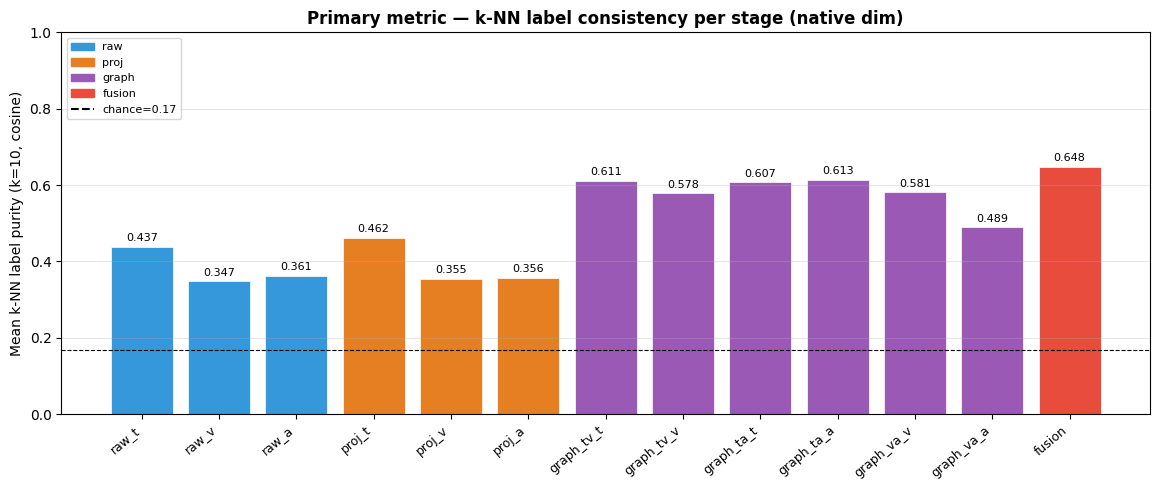

Saved: knn_purity_by_stage.png


In [18]:
# Plot A — mean kNN purity per stage
vals = [purity_mean[k] for k in FEAT_KEYS]
bar_c = [GROUP_COLOR[stage_group(k)] for k in FEAT_KEYS]

fig, ax = plt.subplots(figsize=(max(8, len(FEAT_KEYS) * 0.9), 5))
bars = ax.bar(range(len(FEAT_KEYS)), vals, color=bar_c, edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(FEAT_KEYS)))
ax.set_xticklabels(FEAT_KEYS, rotation=40, ha='right', fontsize=9)
ax.set_ylabel(f'Mean k-NN label purity (k={K_PRIMARY}, cosine)')
ax.set_title('Primary metric — k-NN label consistency per stage (native dim)',
             fontsize=12, fontweight='bold')
ax.axhline(1.0 / N_EMO, color='black', ls='--', lw=0.8, label=f'chance = {1/N_EMO:.2f}')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
from matplotlib.patches import Patch
grp_leg = [Patch(color=GROUP_COLOR[g], label=g) for g in ['raw','proj','graph','fusion']]
ax.legend(handles=grp_leg + [plt.Line2D([0],[0], color='black', ls='--', label=f'chance={1/N_EMO:.2f}')],
          fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig('knn_purity_by_stage.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: knn_purity_by_stage.png')

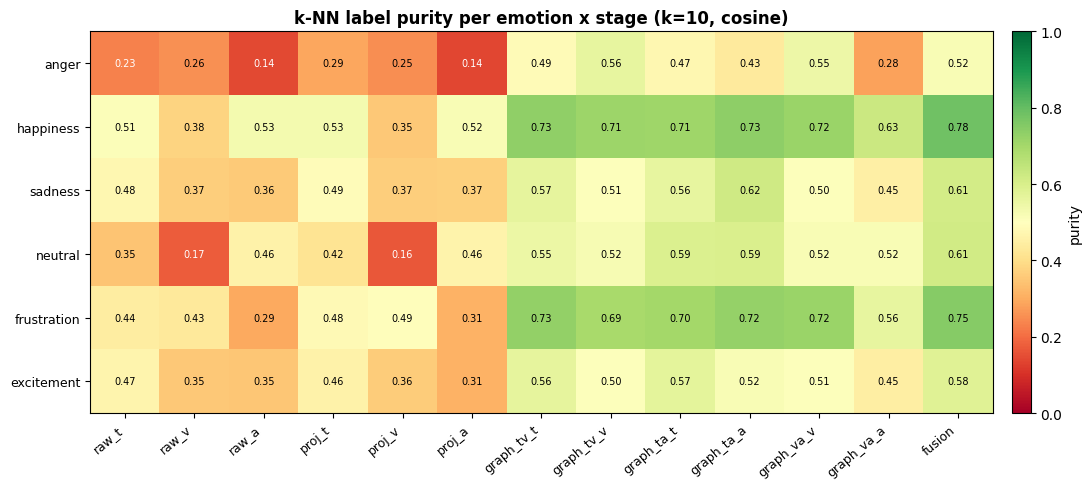

Saved: knn_purity_heatmap.png


In [19]:
# Plot B — kNN purity heatmap: emotion x stage
M = np.array([[purity_by_emo[k][c] for k in FEAT_KEYS] for c in range(N_EMO)])

fig, ax = plt.subplots(figsize=(max(8, len(FEAT_KEYS) * 0.85), 5))
im = ax.imshow(M, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(FEAT_KEYS)))
ax.set_xticklabels(FEAT_KEYS, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(N_EMO))
ax.set_yticklabels([EMOTION_LABELS[c] for c in range(N_EMO)], fontsize=9)
ax.set_title(f'k-NN label purity per emotion x stage (k={K_PRIMARY}, cosine)',
             fontsize=12, fontweight='bold')
for i in range(N_EMO):
    for j in range(len(FEAT_KEYS)):
        ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center', fontsize=7,
                color='black' if 0.25 < M[i,j] < 0.85 else 'white')
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='purity')
plt.tight_layout()
plt.savefig('knn_purity_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: knn_purity_heatmap.png')

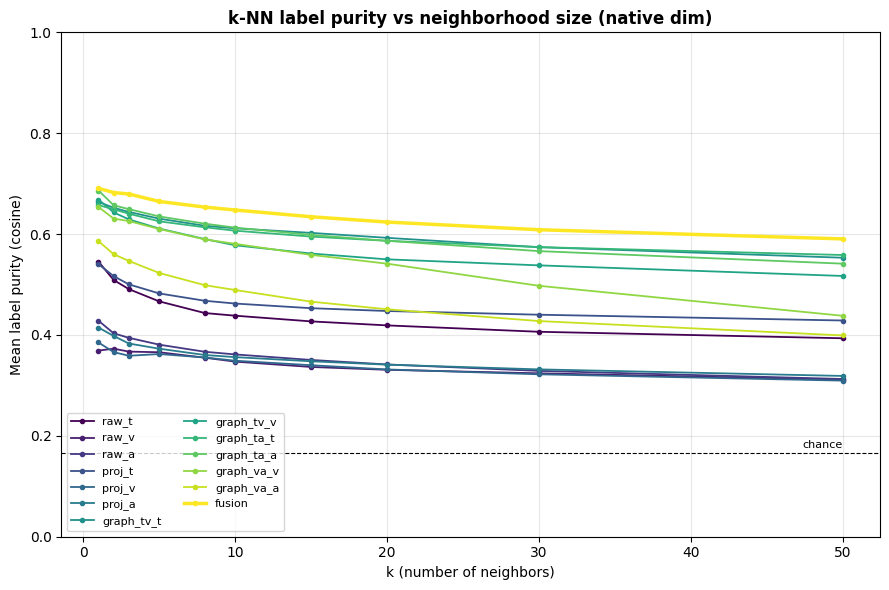

Saved: knn_purity_vs_k.png


In [20]:
# Plot C — purity vs k curve, one line per stage
KS = [1, 2, 3, 5, 8, 10, 15, 20, 30, 50]

fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.cm.viridis(np.linspace(0, 1, len(FEAT_KEYS)))
for key, col in zip(FEAT_KEYS, cmap):
    ys = knn_purity_vs_k(sf[key], labels, KS)
    lw = 2.5 if key == 'fusion' else 1.3
    ax.plot(KS, ys, marker='o', ms=3, lw=lw, color=col, label=key)
ax.axhline(1.0 / N_EMO, color='black', ls='--', lw=0.8)
ax.text(KS[-1], 1/N_EMO + 0.01, 'chance', ha='right', fontsize=8)
ax.set_xlabel('k (number of neighbors)')
ax.set_ylabel('Mean label purity (cosine)')
ax.set_title('k-NN label purity vs neighborhood size (native dim)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2, loc='lower left')
plt.tight_layout()
plt.savefig('knn_purity_vs_k.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: knn_purity_vs_k.png')

## SECONDARY — per-class silhouette (cosine, native space)

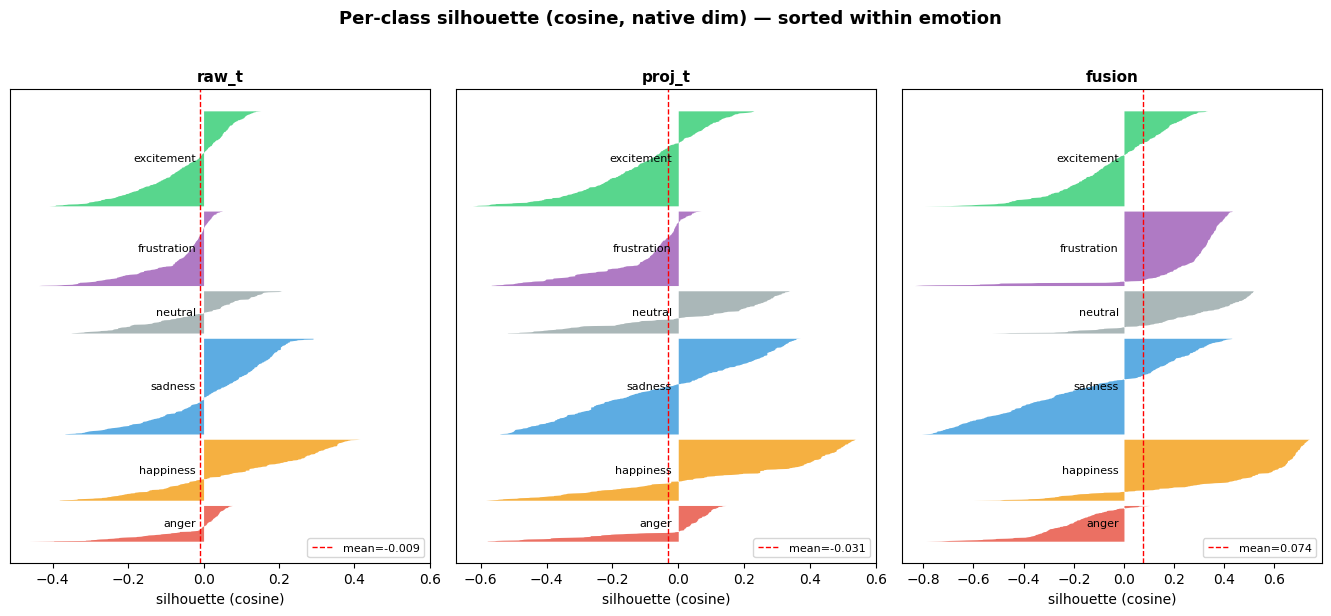

Saved: silhouette_knife.png


In [21]:
# Plot D — classic silhouette 'knife' plot for selected stages (raw vs fusion)
def silhouette_knife(ax, sil, sub_lab, title):
    y_low = 0
    for c in range(N_EMO):
        vals = np.sort(sil[sub_lab == c])
        y_high = y_low + len(vals)
        ax.fill_betweenx(np.arange(y_low, y_high), 0, vals,
                         color=COLORS[c], alpha=0.8, linewidth=0)
        ax.text(-0.02, (y_low + y_high) / 2, EMOTION_LABELS[c],
                ha='right', va='center', fontsize=8)
        y_low = y_high + 20
    ax.axvline(sil.mean(), color='red', ls='--', lw=1, label=f'mean={sil.mean():.3f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('silhouette (cosine)')
    ax.set_yticks([])
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(min(-0.3, sil.min() - 0.05), max(0.6, sil.max() + 0.05))

knife_stages = [k for k in ['raw_t', 'proj_t', 'fusion'] if k in sf]
fig, axes = plt.subplots(1, len(knife_stages), figsize=(len(knife_stages) * 4.5, 6))
if len(knife_stages) == 1:
    axes = [axes]
for ax, key in zip(axes, knife_stages):
    sil, _, sub_lab = sil_data[key]
    silhouette_knife(ax, sil, sub_lab, key)
fig.suptitle('Per-class silhouette (cosine, native dim) — sorted within emotion',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('silhouette_knife.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: silhouette_knife.png')

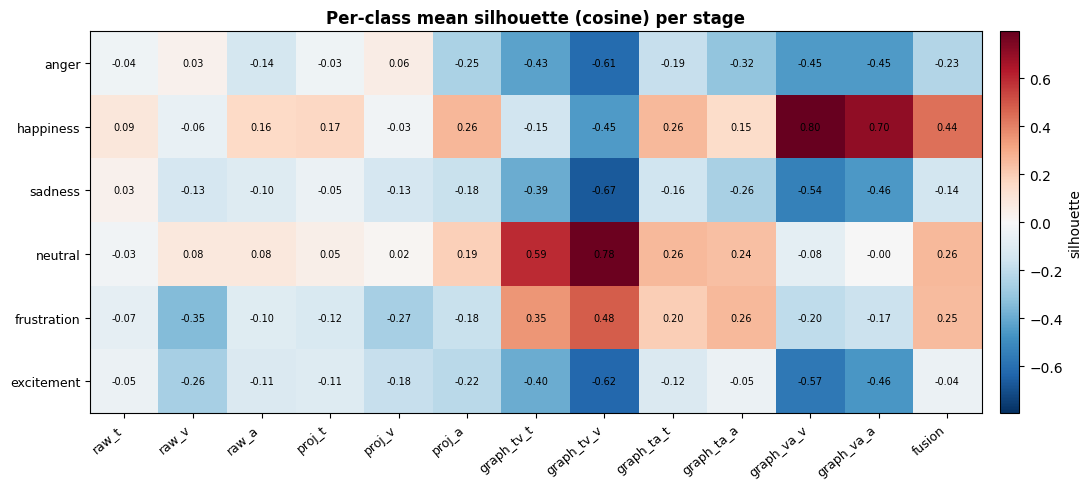

Saved: silhouette_by_stage.png


In [22]:
# Plot E — per-class mean silhouette heatmap: emotion x stage
S = np.array([[sil_class[k][c] for k in FEAT_KEYS] for c in range(N_EMO)])
vmax = np.abs(S).max()

fig, ax = plt.subplots(figsize=(max(8, len(FEAT_KEYS) * 0.85), 5))
im = ax.imshow(S, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(FEAT_KEYS)))
ax.set_xticklabels(FEAT_KEYS, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(N_EMO))
ax.set_yticklabels([EMOTION_LABELS[c] for c in range(N_EMO)], fontsize=9)
ax.set_title('Per-class mean silhouette (cosine) per stage', fontsize=12, fontweight='bold')
for i in range(N_EMO):
    for j in range(len(FEAT_KEYS)):
        ax.text(j, i, f'{S[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='silhouette')
plt.tight_layout()
plt.savefig('silhouette_by_stage.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: silhouette_by_stage.png')

## SUPPORTING — inter-emotion centroid cosine distance

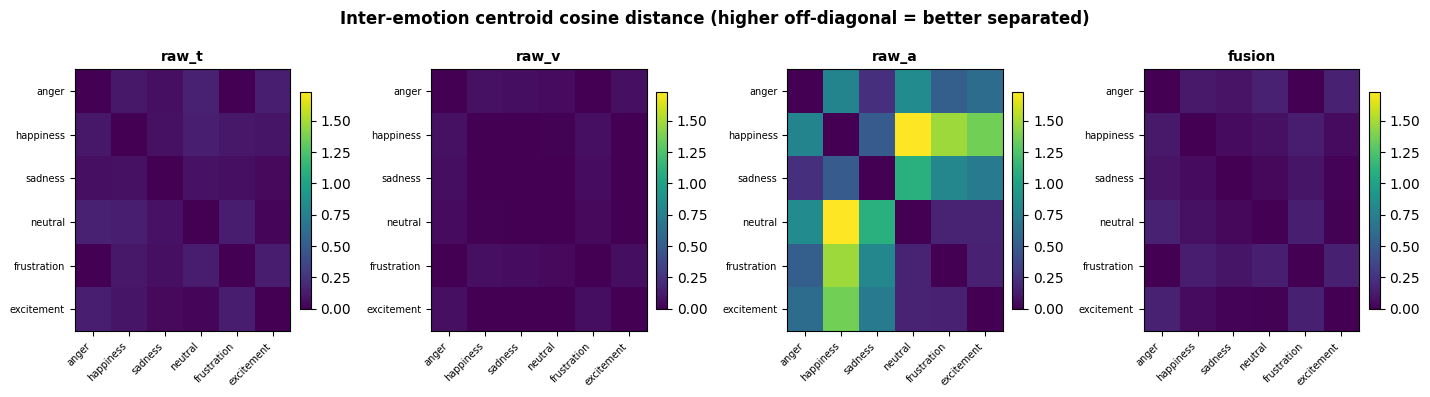

Saved: centroid_cosine_heatmap.png


In [23]:
# Plot F — pairwise centroid cosine-distance heatmap for key stages
cd_stages = [k for k in ['raw_t', 'raw_v', 'raw_a', 'fusion'] if k in sf]
emo_names = [EMOTION_LABELS[c] for c in range(N_EMO)]

fig, axes = plt.subplots(1, len(cd_stages), figsize=(len(cd_stages) * 3.6, 4))
if len(cd_stages) == 1:
    axes = [axes]
vmax = max(centroid_dist[k].max() for k in cd_stages)
for ax, key in zip(axes, cd_stages):
    D = centroid_dist[key]
    im = ax.imshow(D, cmap='viridis', vmin=0, vmax=vmax, aspect='auto')
    ax.set_xticks(range(N_EMO)); ax.set_yticks(range(N_EMO))
    ax.set_xticklabels(emo_names, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(emo_names, fontsize=7)
    ax.set_title(key, fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle('Inter-emotion centroid cosine distance (higher off-diagonal = better separated)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('centroid_cosine_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: centroid_cosine_heatmap.png')

## DIRECT VISUAL — do emotions form clusters at each stage? (all samples, native dim, no projection)

Two ways to *see* clustering without collapsing dimensionality:

1. **Sorted cosine-similarity block matrix** — sort every sample by emotion, plot the full N×N pairwise cosine similarity. If same-emotion vectors are alike, bright squares appear on the diagonal (one block per emotion). Uniform texture = no clustering.
2. **Intra- vs inter-emotion cosine-distance histograms** — same-emotion pair distances (green) vs different-emotion pair distances (gray). A leftward-shifted green curve means same-emotion vectors sit closer together than random pairs → clusters exist. The `gap` = how much closer.

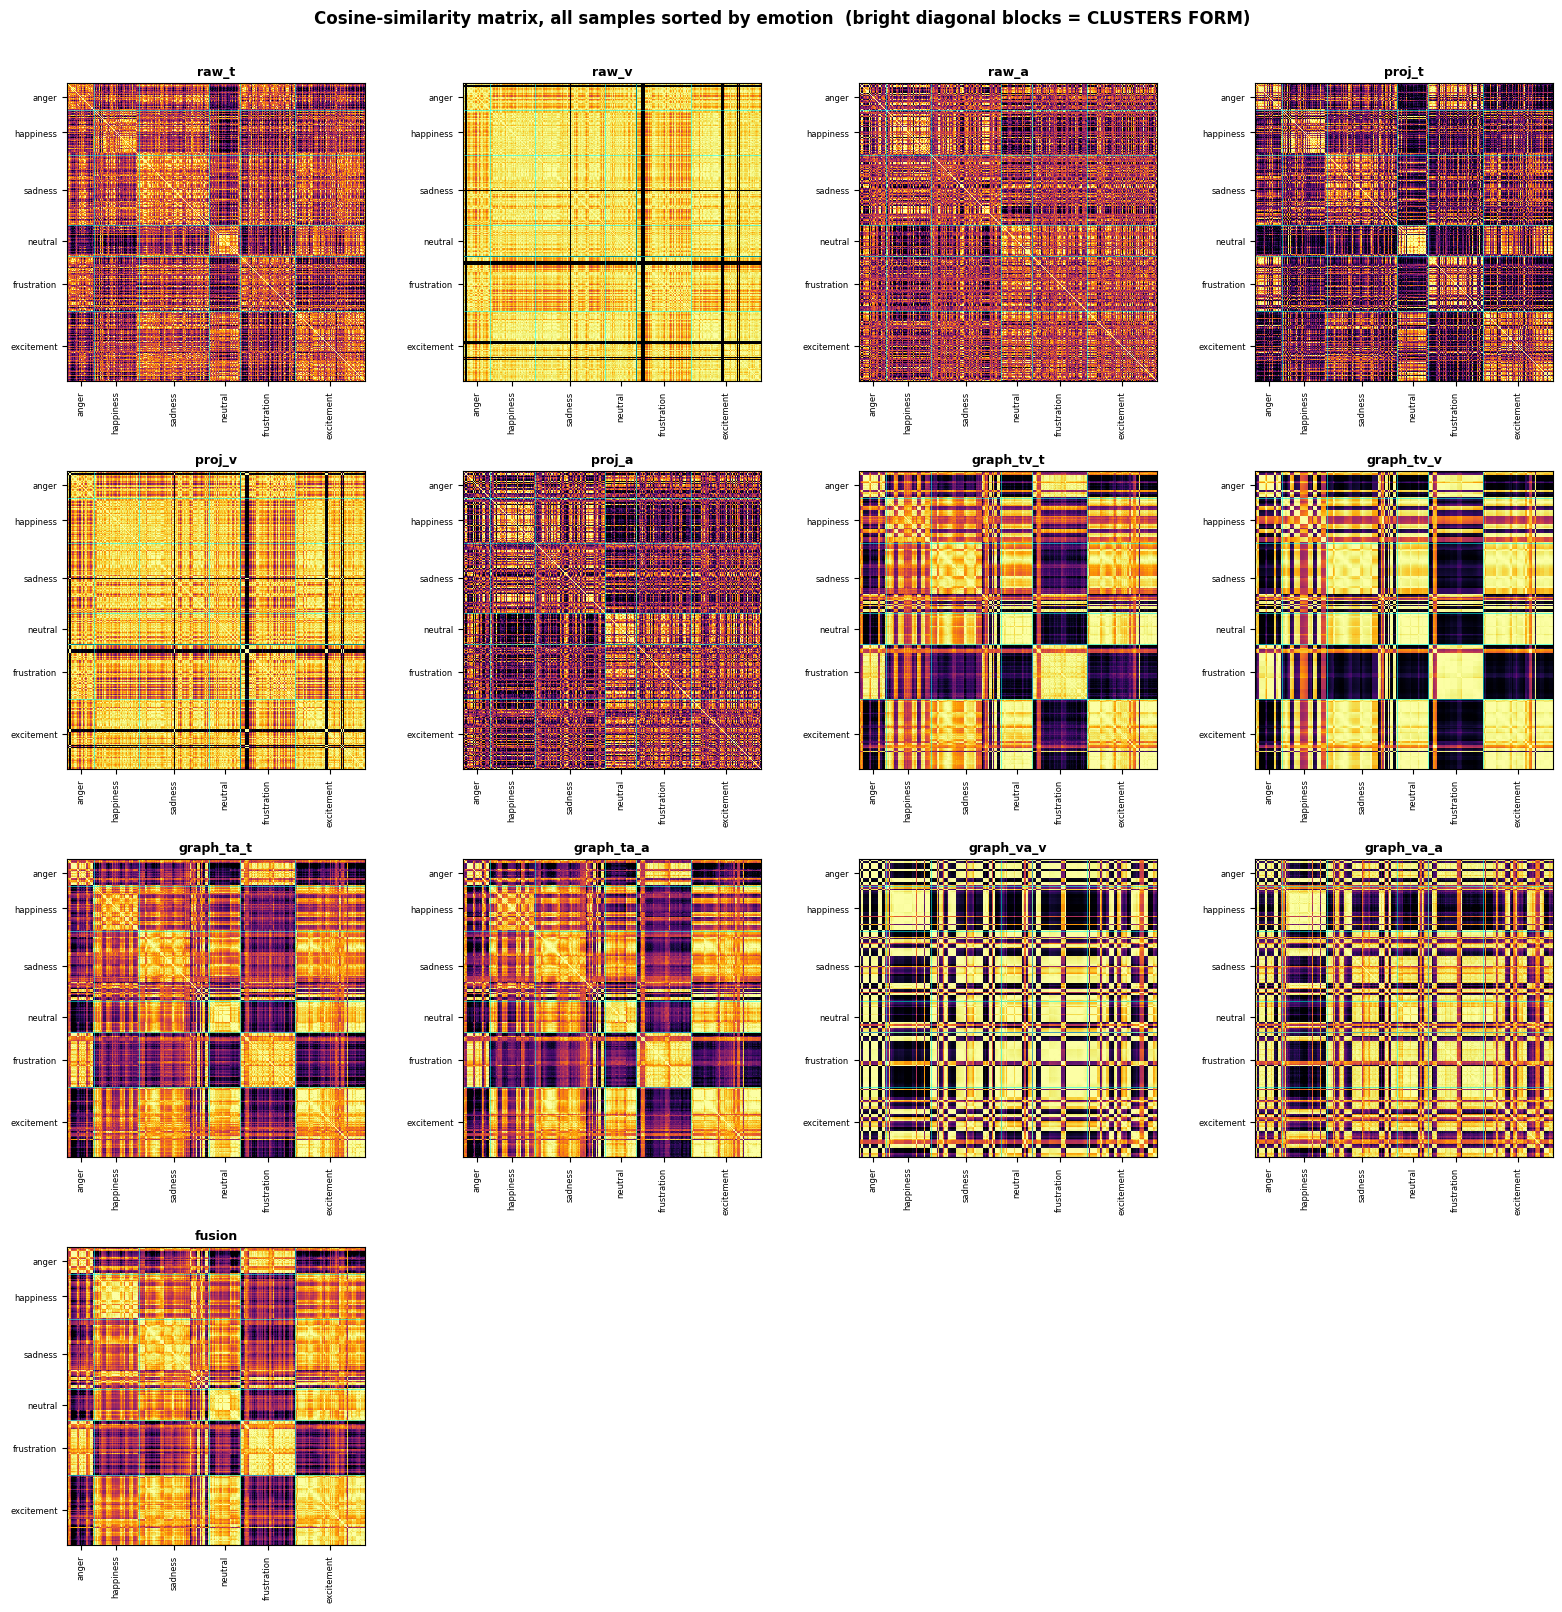

Saved: cluster_block_matrix.png


In [24]:
# ── DIRECT VISUAL 1 — sorted cosine-similarity block matrix ──
# Sort ALL samples by emotion label, then plot the full N x N pairwise cosine
# similarity. Bright block-diagonal squares = same-emotion vectors are similar
# = CLUSTERS FORM. Uniform texture = no clustering. No projection anywhere.

order = np.argsort(labels, kind='stable')      # group samples by emotion
lab_sorted = labels[order]
bounds = np.where(np.diff(lab_sorted) != 0)[0] + 1     # class boundary rows
centers, start = [], 0
for b in list(bounds) + [len(lab_sorted)]:
    centers.append((start + b) / 2)
    start = b

cols = 4
rows = (len(FEAT_KEYS) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()
for i, key in enumerate(FEAT_KEYS):
    Xn = l2norm(sf[key][order])
    S = Xn @ Xn.T                              # cosine similarity, all samples
    vlo, vhi = np.percentile(S, [2, 98])       # stretch contrast to reveal blocks
    ax = axes[i]
    ax.imshow(S, cmap='inferno', vmin=vlo, vmax=vhi, aspect='equal', interpolation='nearest')
    for b in bounds:
        ax.axhline(b - 0.5, color='cyan', lw=0.4)
        ax.axvline(b - 0.5, color='cyan', lw=0.4)
    ax.set_title(key, fontsize=9, fontweight='bold')
    ax.set_xticks(centers); ax.set_yticks(centers)
    ax.set_xticklabels([EMOTION_LABELS[c] for c in range(N_EMO)], rotation=90, fontsize=6)
    ax.set_yticklabels([EMOTION_LABELS[c] for c in range(N_EMO)], fontsize=6)
for j in range(len(FEAT_KEYS), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Cosine-similarity matrix, all samples sorted by emotion  '
             '(bright diagonal blocks = CLUSTERS FORM)',
             fontsize=12, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('cluster_block_matrix.png', dpi=110, bbox_inches='tight')
plt.show()
print('Saved: cluster_block_matrix.png')

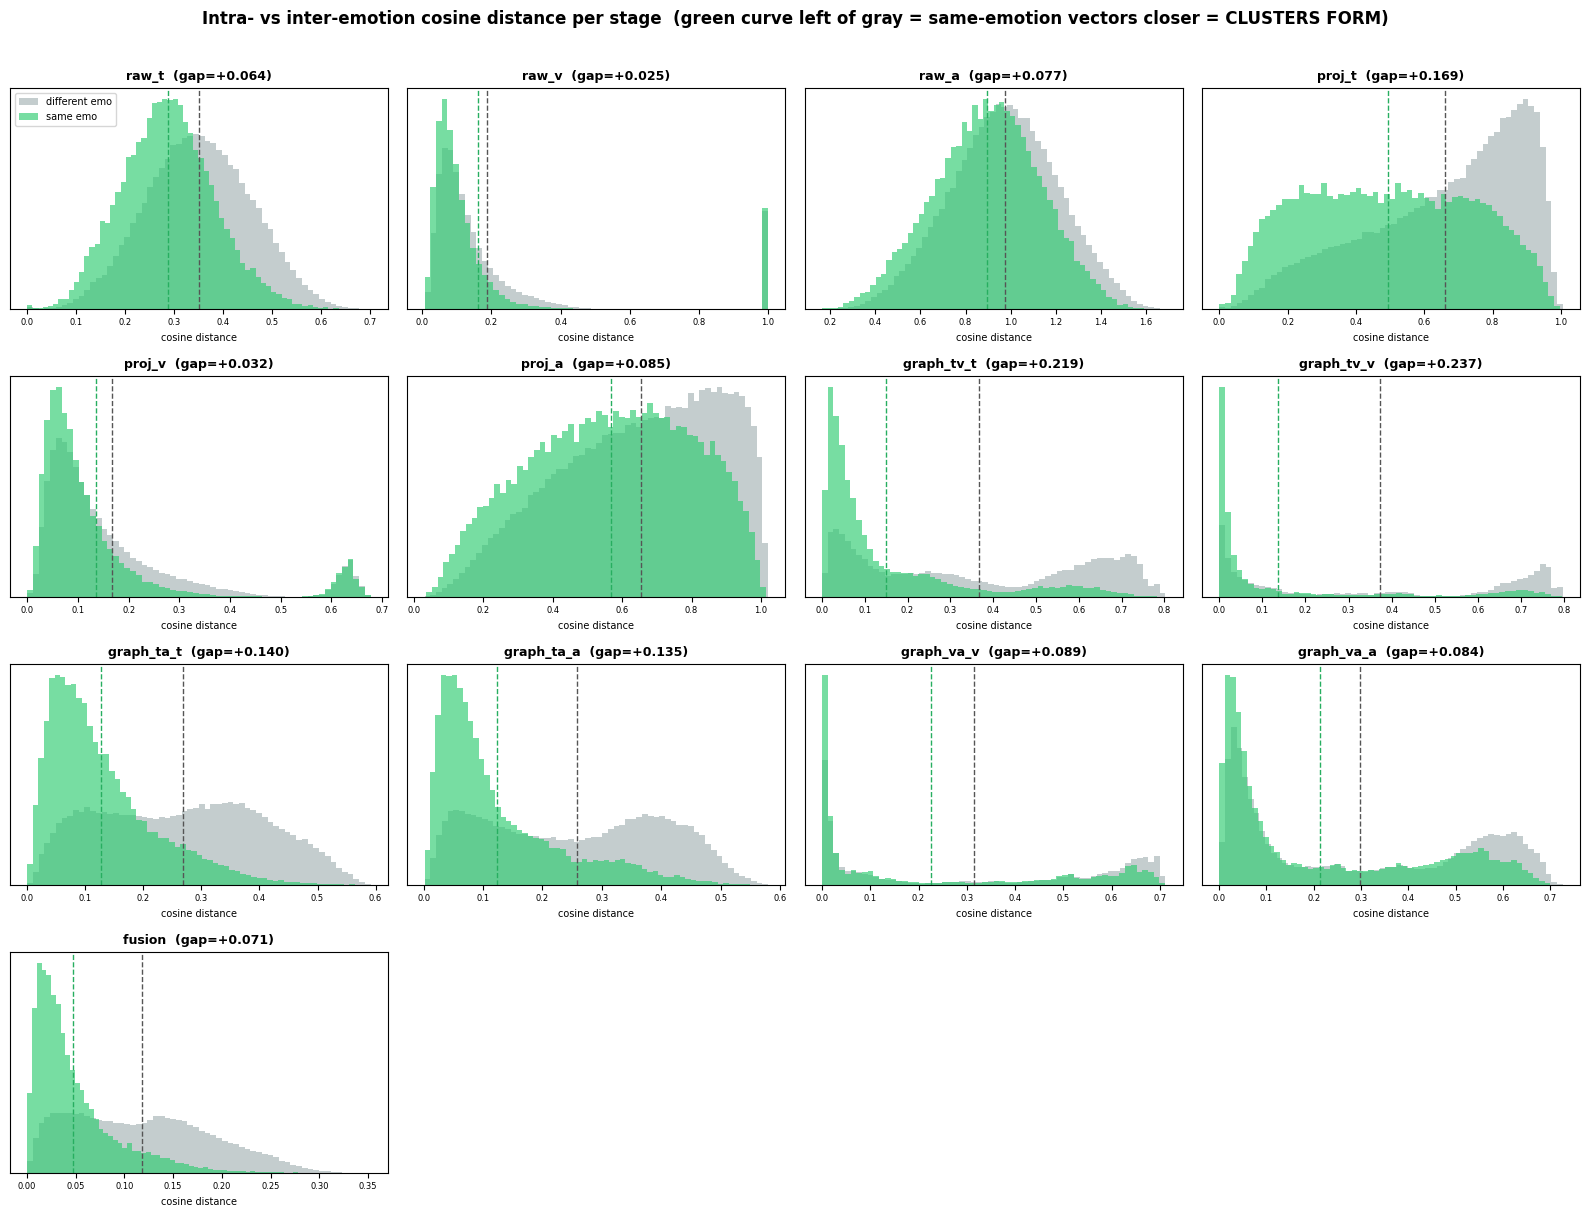

Saved: cluster_intra_inter_hist.png

Separation gap (inter_mean - intra_mean), higher = tighter clusters:
  raw_t       : gap=+0.0640
  raw_v       : gap=+0.0252
  raw_a       : gap=+0.0771
  proj_t      : gap=+0.1689
  proj_v      : gap=+0.0316
  proj_a      : gap=+0.0853
  graph_tv_t  : gap=+0.2188
  graph_tv_v  : gap=+0.2368
  graph_ta_t  : gap=+0.1395
  graph_ta_a  : gap=+0.1350
  graph_va_v  : gap=+0.0890
  graph_va_a  : gap=+0.0837
  fusion      : gap=+0.0706


In [25]:
# ── DIRECT VISUAL 2 — intra- vs inter-emotion cosine-distance distributions ──
# Uses ALL samples as the population; samples random pairs. Native dim, cosine.
# same-emotion curve LEFT of different-emotion curve = emotions cluster.

def intra_inter_cosdist(X, labels, n_pairs=200000, seed=RANDOM_SEED):
    Xn = l2norm(X)
    rng = np.random.RandomState(seed)
    i = rng.randint(0, len(labels), n_pairs)
    j = rng.randint(0, len(labels), n_pairs)
    m = i != j
    i, j = i[m], j[m]
    d = 1.0 - (Xn[i] * Xn[j]).sum(axis=1)      # cosine distance per pair
    same = labels[i] == labels[j]
    return d[same], d[~same]

cols = 4
rows = (len(FEAT_KEYS) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten()
for i, key in enumerate(FEAT_KEYS):
    intra, inter = intra_inter_cosdist(sf[key], labels)
    ax = axes[i]
    ax.hist(inter, bins=60, density=True, alpha=0.55, color='#95a5a6', label='different emo')
    ax.hist(intra, bins=60, density=True, alpha=0.65, color='#2ecc71', label='same emo')
    ax.axvline(intra.mean(), color='#27ae60', ls='--', lw=1)
    ax.axvline(inter.mean(), color='#555', ls='--', lw=1)
    gap = inter.mean() - intra.mean()          # positive gap = clustering
    ax.set_title(f'{key}  (gap={gap:+.3f})', fontsize=9, fontweight='bold')
    ax.set_xlabel('cosine distance', fontsize=7)
    ax.set_yticks([])
    ax.tick_params(labelsize=6)
    if i == 0:
        ax.legend(fontsize=7, loc='upper left')
for j in range(len(FEAT_KEYS), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Intra- vs inter-emotion cosine distance per stage  '
             '(green curve left of gray = same-emotion vectors closer = CLUSTERS FORM)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('cluster_intra_inter_hist.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: cluster_intra_inter_hist.png')

print('\nSeparation gap (inter_mean - intra_mean), higher = tighter clusters:')
for key in FEAT_KEYS:
    intra, inter = intra_inter_cosdist(sf[key], labels)
    print(f'  {key:12s}: gap={inter.mean()-intra.mean():+.4f}')

## Summary

In [26]:
print('=' * 60)
print('CLUSTER-QUALITY SUMMARY (native dim, cosine)')
print('=' * 60)
print(f'\nBest kNN label purity : {best_p:12s} = {purity_mean[best_p]:.3f}')
print(f'Best mean silhouette  : {best_s:12s} = {sil_data[best_s][0].mean():.3f}')

print('\nRaw -> Fusion improvement:')
for raw_key in ['raw_t', 'raw_v', 'raw_a']:
    if raw_key in sf and 'fusion' in sf:
        dp = purity_mean['fusion'] - purity_mean[raw_key]
        print(f'  purity  {raw_key} {purity_mean[raw_key]:.3f} -> fusion {purity_mean["fusion"]:.3f}  (Δ {dp:+.3f})')

if 'fusion' in sf:
    print('\nHardest emotions at fusion stage (lowest kNN purity):')
    hard = sorted(range(N_EMO), key=lambda c: purity_by_emo['fusion'][c])[:3]
    for c in hard:
        print(f'  {EMOTION_LABELS[c]:12s}: purity={purity_by_emo["fusion"][c]:.3f}, '
              f'silhouette={sil_class["fusion"][c]:.3f}')
    print('\nClosest emotion pairs at fusion (smallest centroid cosine distance):')
    D = centroid_dist['fusion']
    pairs = [(i, j, D[i, j]) for i in range(N_EMO) for j in range(i+1, N_EMO)]
    for i, j, d in sorted(pairs, key=lambda x: x[2])[:3]:
        print(f'  {EMOTION_LABELS[i]:12s} <-> {EMOTION_LABELS[j]:12s}: cos-dist={d:.3f}')

CLUSTER-QUALITY SUMMARY (native dim, cosine)

Best kNN label purity : fusion       = 0.648
Best mean silhouette  : fusion       = 0.074

Raw -> Fusion improvement:
  purity  raw_t 0.437 -> fusion 0.648  (Δ +0.210)
  purity  raw_v 0.347 -> fusion 0.648  (Δ +0.300)
  purity  raw_a 0.361 -> fusion 0.648  (Δ +0.286)

Hardest emotions at fusion stage (lowest kNN purity):
  anger       : purity=0.519, silhouette=-0.233
  excitement  : purity=0.581, silhouette=-0.044
  sadness     : purity=0.613, silhouette=-0.145

Closest emotion pairs at fusion (smallest centroid cosine distance):
  anger        <-> frustration : cos-dist=0.004
  neutral      <-> excitement  : cos-dist=0.009
  sadness      <-> excitement  : cos-dist=0.019
